# Fruit classification

## Apple, Banana, Orange

## Train, Valid, Test

## ~70%/15%/15%

In [1]:
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.preprocessing.image import ImageDataGenerator

# 1, Training
## Define base model

Input shape 64x64x3, dense, dense, dense

In [2]:
num_classes = 3

model = Sequential([
    Flatten(input_shape=(64, 64, 3)),
    Dense(512, activation='relu', input_shape=(64,)),
    Dense(512, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 12288)             0         
_________________________________________________________________
dense (Dense)                (None, 512)               6291968   
_________________________________________________________________
dense_1 (Dense)              (None, 512)               262656    
_________________________________________________________________
dense_2 (Dense)              (None, 3)                 1539      
Total params: 6,556,163
Trainable params: 6,556,163
Non-trainable params: 0
_________________________________________________________________


## Define train/valid directory and images (64x64)

In [3]:
TRAINING_DIR = "./train"
train_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(TRAINING_DIR, 
                                                    batch_size=10, 
                                                    target_size=(64, 64))

VALIDATION_DIR = "./valid"
validation_datagen = ImageDataGenerator(rescale=1.0/255)

validation_generator = validation_datagen.flow_from_directory(VALIDATION_DIR, 
                                                         batch_size=10, 
                                                         target_size=(64, 64))

Found 464 images belonging to 3 classes.
Found 96 images belonging to 3 classes.


## Train and save the model

In [4]:
history = model.fit(train_generator,
                    epochs=5,
                    validation_data=validation_generator)
model.save("fruit.h5")

Epoch 1/5
47/47 [==============================] - 15s 100ms/step - loss: 6.7795 - acc: 0.4144 - val_loss: 0.3518 - val_acc: 0.8958
Epoch 2/5
47/47 [==============================] - 4s 91ms/step - loss: 0.4758 - acc: 0.8220 - val_loss: 0.6515 - val_acc: 0.7188
Epoch 3/5
47/47 [==============================] - 4s 92ms/step - loss: 0.6138 - acc: 0.8041 - val_loss: 0.4136 - val_acc: 0.8021
Epoch 4/5
47/47 [==============================] - 4s 92ms/step - loss: 0.3623 - acc: 0.8460 - val_loss: 0.3709 - val_acc: 0.8438
Epoch 5/5
47/47 [==============================] - 4s 93ms/step - loss: 0.4407 - acc: 0.8396 - val_loss: 0.2333 - val_acc: 0.9167


## See the training accuracy/loss

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print(history.history.keys())
epochs=5

val_acc = history.history['val_acc']
val_loss = history.history['val_loss']
acc = history.history['acc']
loss = history.history['loss']

plt.plot(range(epochs), acc, 'b*-', label = 'Training accuracy')
plt.plot(range(epochs), val_acc, 'r', label = 'Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()

dict_keys(['loss', 'acc', 'val_loss', 'val_acc'])


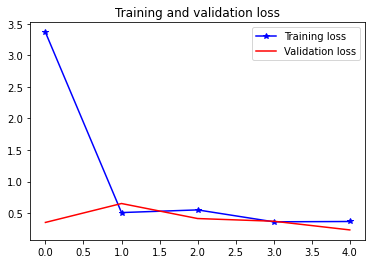

In [6]:
plt.plot(range(epochs), loss, 'b*-', label = 'Training loss')
plt.plot(range(epochs), val_loss, 'r', label = 'Validation loss')
plt.title('Training and validation loss')
plt.legend()

# 2, Inference

## First, load the trained model, then image to predict

array([[1., 0., 0.]], dtype=float32)

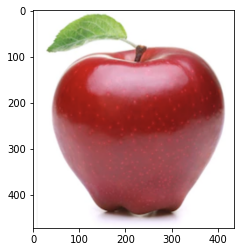

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing import image as image_utils
from tensorflow.keras.applications.imagenet_utils import preprocess_input
from tensorflow import keras

model = keras.models.load_model('fruit.h5')

image_path = './test/Apple/1.png'

image = mpimg.imread(image_path)
plt.imshow(image)

def make_prediction(image_path):
    image = image_utils.load_img(image_path, target_size=(64, 64))
    image = image_utils.img_to_array(image)
    image = image.reshape(1,64,64,3)
    image = preprocess_input(image)
    preds = model.predict(image)
    return preds

make_prediction('./test/Apple/1.png')

## It's better to define the mapping for index/name

In [8]:
import numpy as np

image_mapping = {0: 'Apple', 1: 'Banana', 2: 'Orange'}
    
print(image_mapping[np.argmax(make_prediction('./test/Apple/1.png'))])

Apple


## Run the model inference for "test" dataset

In [9]:
test_datagen = ImageDataGenerator(rescale=1.0/255)
test_it = test_datagen.flow_from_directory('./test/', 
                                       target_size=(64, 64), 
                                       batch_size=1, 
                                       shuffle=False,
                                       class_mode="categorical")

pred_output = model.predict(test_it)
print(pred_output)
pred_output = np.argmax(pred_output, axis=1)
print(pred_output)

Found 96 images belonging to 3 classes.
[[9.99717414e-01 7.61995398e-05 2.06380559e-04]
 [9.98612165e-01 5.40064175e-05 1.33379316e-03]
 [9.74701107e-01 4.01352590e-04 2.48976070e-02]
 [9.97940600e-01 3.66428139e-05 2.02276162e-03]
 [9.94269848e-01 6.22014195e-05 5.66794258e-03]
 [9.96949017e-01 1.02489954e-03 2.02602451e-03]
 [9.98789608e-01 3.30040406e-04 8.80399894e-04]
 [9.98547733e-01 7.73053674e-04 6.79263962e-04]
 [9.99812782e-01 2.18612022e-05 1.65386693e-04]
 [9.81595814e-01 1.45035237e-02 3.90074053e-03]
 [9.72946525e-01 3.85612482e-04 2.66677421e-02]
 [9.99591887e-01 3.31178453e-05 3.74991534e-04]
 [9.99317050e-01 2.00758077e-04 4.82233794e-04]
 [9.95173275e-01 8.53044796e-04 3.97365121e-03]
 [8.20131481e-01 1.62744239e-01 1.71243772e-02]
 [9.98627186e-01 3.67744011e-04 1.00505422e-03]
 [9.99176562e-01 6.36417608e-05 7.59763410e-04]
 [9.80265141e-01 1.91187002e-02 6.16192294e-04]
 [2.94838607e-01 5.00601649e-01 2.04559758e-01]
 [2.49010235e-01 7.50760257e-01 2.29464800e-04]


## See the classification report

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(test_it.classes, pred_output))

              precision    recall  f1-score   support

           0       0.94      0.91      0.92        32
           1       0.84      1.00      0.91        32
           2       1.00      0.84      0.92        32

   micro avg       0.92      0.92      0.92        96
   macro avg       0.93      0.92      0.92        96
weighted avg       0.93      0.92      0.92        96



## See the confusion matrix

Text(0.5, 1.0, 'Confusion matrix of model')

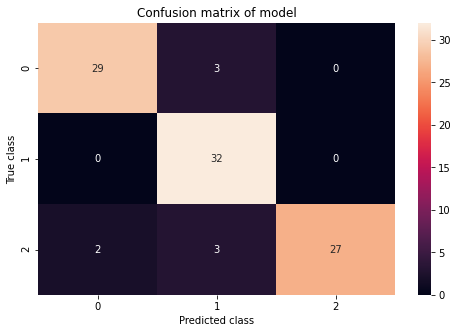

In [11]:
cf_matrix = confusion_matrix(test_it.classes, pred_output)

plt.figure(figsize=(8,5))
heatmap = sns.heatmap(cf_matrix, annot=True, fmt='d', color='blue')
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title('Confusion matrix of model')